In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


# Start

In [3]:
df = pd.read_csv('train.csv')
df.head()

,id,num_1,num_2,num_3,num_4,num_5,num_6,num_7,num_8,num_9,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7,target
0,0,68,15136,148531,491,80,4,14.98,12,0.55,Bachelor's,Self-employed,Divorced,No,No,Auto,Yes,1
1,1,66,148756,40664,825,16,4,11.32,48,0.25,Bachelor's,Unemployed,Single,Yes,No,Other,No,0
2,2,61,42190,138134,378,5,1,20.50,48,0.79,Bachelor's,Unemployed,Married,Yes,No,Education,Yes,0
3,3,21,89531,33212,558,72,1,14.61,12,0.48,High School,Part-time,Divorced,No,Yes,Auto,Yes,1
4,4,60,36068,72656,659,25,3,7.84,60,0.82,PhD,Part-time,Single,No,Yes,Business,No,0


In [4]:
df.rename({
    'num_1': 'umur',
    'num_2': 'pendapatan',
    'num_3': 'pinjaman',
    'num_4': 'skor_kredit',
    'num_5': 'bulan_bekerja',
    'num_6': 'jumlah_akun_kredit_yang_aktif',
    'num_7': 'interest',
    'num_8': 'bulan_pinjaman',
    'num_9': 'ratio_debt_to_income',
    'cat_1': 'level_edukasi',
    'cat_2': 'jenis_pekerjaan',
    'cat_3': 'status_menikah',
    'cat_4': 'ada_mortgage',
    'cat_5': 'punya_tanggungan',
    'cat_6': 'tujuan_loan',
    'cat_7': 'ada_cosigner',
    'target': 'loan_default_status'
}, axis=1, inplace=True)
df.head()

,id,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,level_edukasi,jenis_pekerjaan,status_menikah,ada_mortgage,punya_tanggungan,tujuan_loan,ada_cosigner,loan_default_status
0,0,68,15136,148531,491,80,4,14.98,12,0.55,Bachelor's,Self-employed,Divorced,No,No,Auto,Yes,1
1,1,66,148756,40664,825,16,4,11.32,48,0.25,Bachelor's,Unemployed,Single,Yes,No,Other,No,0
2,2,61,42190,138134,378,5,1,20.50,48,0.79,Bachelor's,Unemployed,Married,Yes,No,Education,Yes,0
3,3,21,89531,33212,558,72,1,14.61,12,0.48,High School,Part-time,Divorced,No,Yes,Auto,Yes,1
4,4,60,36068,72656,659,25,3,7.84,60,0.82,PhD,Part-time,Single,No,Yes,Business,No,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             38000 non-null  int64  
 1   umur                           38000 non-null  int64  
 2   pendapatan                     38000 non-null  int64  
 3   pinjaman                       38000 non-null  int64  
 4   skor_kredit                    38000 non-null  int64  
 5   bulan_bekerja                  38000 non-null  int64  
 6   jumlah_akun_kredit_yang_aktif  38000 non-null  int64  
 7   interest                       38000 non-null  float64
 8   bulan_pinjaman                 38000 non-null  int64  
 9   ratio_debt_to_income           38000 non-null  float64
 10  level_edukasi                  38000 non-null  object 
 11  jenis_pekerjaan                38000 non-null  object 
 12  status_menikah                 38000 non-null 

In [6]:
df.describe()

,id,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,loan_default_status
count,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000,38000.000000
mean,18999.500000,41.350184,79257.395316,133175.401553,570.365842,56.736921,2.534105,14.246398,36.017684,0.504017,0.394737
std,10969.799451,15.024800,39854.914883,70800.991665,159.348195,34.831082,1.120539,6.658927,16.941723,0.229774,0.488801
min,0.000000,18.000000,15006.000000,4999.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,9499.750000,28.000000,43717.750000,72613.750000,432.000000,26.000000,2.000000,8.570000,24.000000,0.310000,0.000000
50%,18999.500000,40.000000,78135.500000,135945.500000,568.000000,55.000000,3.000000,14.620000,36.000000,0.510000,0.000000
75%,28499.250000,54.000000,113869.250000,195121.250000,708.000000,87.000000,4.000000,20.150000,48.000000,0.700000,1.000000
max,37999.000000,69.000000,149995.000000,249994.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [7]:
df['level_edukasi'].unique()

array(["Bachelor's", 'High School', 'PhD', "Master's"], dtype=object)

In [8]:
df['jenis_pekerjaan'].unique()

array(['Self-employed', 'Unemployed', 'Part-time', 'Full-time'],
      dtype=object)

In [9]:
df['status_menikah'].unique()

array(['Divorced', 'Single', 'Married'], dtype=object)

In [10]:
df['tujuan_loan'].unique()

array(['Auto', 'Other', 'Education', 'Business', 'Home'], dtype=object)

In [11]:
df['ada_mortgage'].unique()

array(['No', 'Yes'], dtype=object)

In [12]:
df['punya_tanggungan'].unique()

array(['No', 'Yes'], dtype=object)

In [13]:
df['ada_cosigner'].unique()


array(['Yes', 'No'], dtype=object)

In [14]:
df[df['loan_default_status'] == 0].describe()

,id,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,loan_default_status
count,23000.000000,23000.000000,23000.000000,23000.000000,23000.000000,23000.000000,23000.000000,23000.000000,23000.000000,23000.000000,23000.0
mean,19001.818957,44.519304,84064.262478,125934.889261,576.570696,60.965217,2.495739,13.145279,36.013565,0.498128,0.0
std,10963.031729,14.884949,38474.956345,70730.548479,158.914215,34.730849,1.117545,6.634941,16.868051,0.230519,0.0
min,1.000000,18.000000,15011.000000,5016.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.0
25%,9492.250000,32.000000,51106.250000,64277.250000,439.000000,31.000000,1.000000,7.400000,24.000000,0.300000,0.0
50%,18956.500000,45.000000,84812.000000,124887.000000,577.000000,62.000000,2.000000,12.930000,36.000000,0.500000,0.0
75%,28525.250000,57.000000,117056.250000,186521.250000,715.000000,91.000000,3.000000,18.862500,48.000000,0.700000,0.0
max,37999.000000,69.000000,149995.000000,249977.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,0.0


loan_status = 1
- rata umur 1 = 44 ; 0 = 36
- pendapatan  1 = 84064 ; 0 = 40798
- pinjaman 1 = 125934 ; 0 = 144277
- skor kredit 1 = 576 ; 0 = 560
- bulan bekerja 1 = 60 ; 0 = 50
- jumlah kredit 1 = 2.4 ; 0 = 2.5

In [15]:
group = df.groupby('loan_default_status').agg({
    'umur':'mean',
    'pendapatan':'mean',
    'pinjaman':'mean',
    'skor_kredit':'mean',
    'bulan_bekerja':'mean',
    'jumlah_akun_kredit_yang_aktif':'mean',
    'interest':'mean',
    'bulan_pinjaman':'mean',
    'ratio_debt_to_income':'mean'
})
group

,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income
loan_default_status,,,,,,,,,
0,44.519304,84064.262478,125934.889261,576.570696,60.965217,2.495739,13.145279,36.013565,0.498128
1,36.490867,71886.865667,144277.520400,560.851733,50.253533,2.592933,15.934782,36.024000,0.513046


# Loan Behavior

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_820\1742987308.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
D:\Users\bsi80273\AppData\Local\Temp\ipykernel_820\1742987308.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
D:\Users\bsi80273\AppData\Local\Temp\ipykernel_820\1742987308.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
D:\Users\bsi80273\AppData\Local\Temp\ipykernel_820\1742987308.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

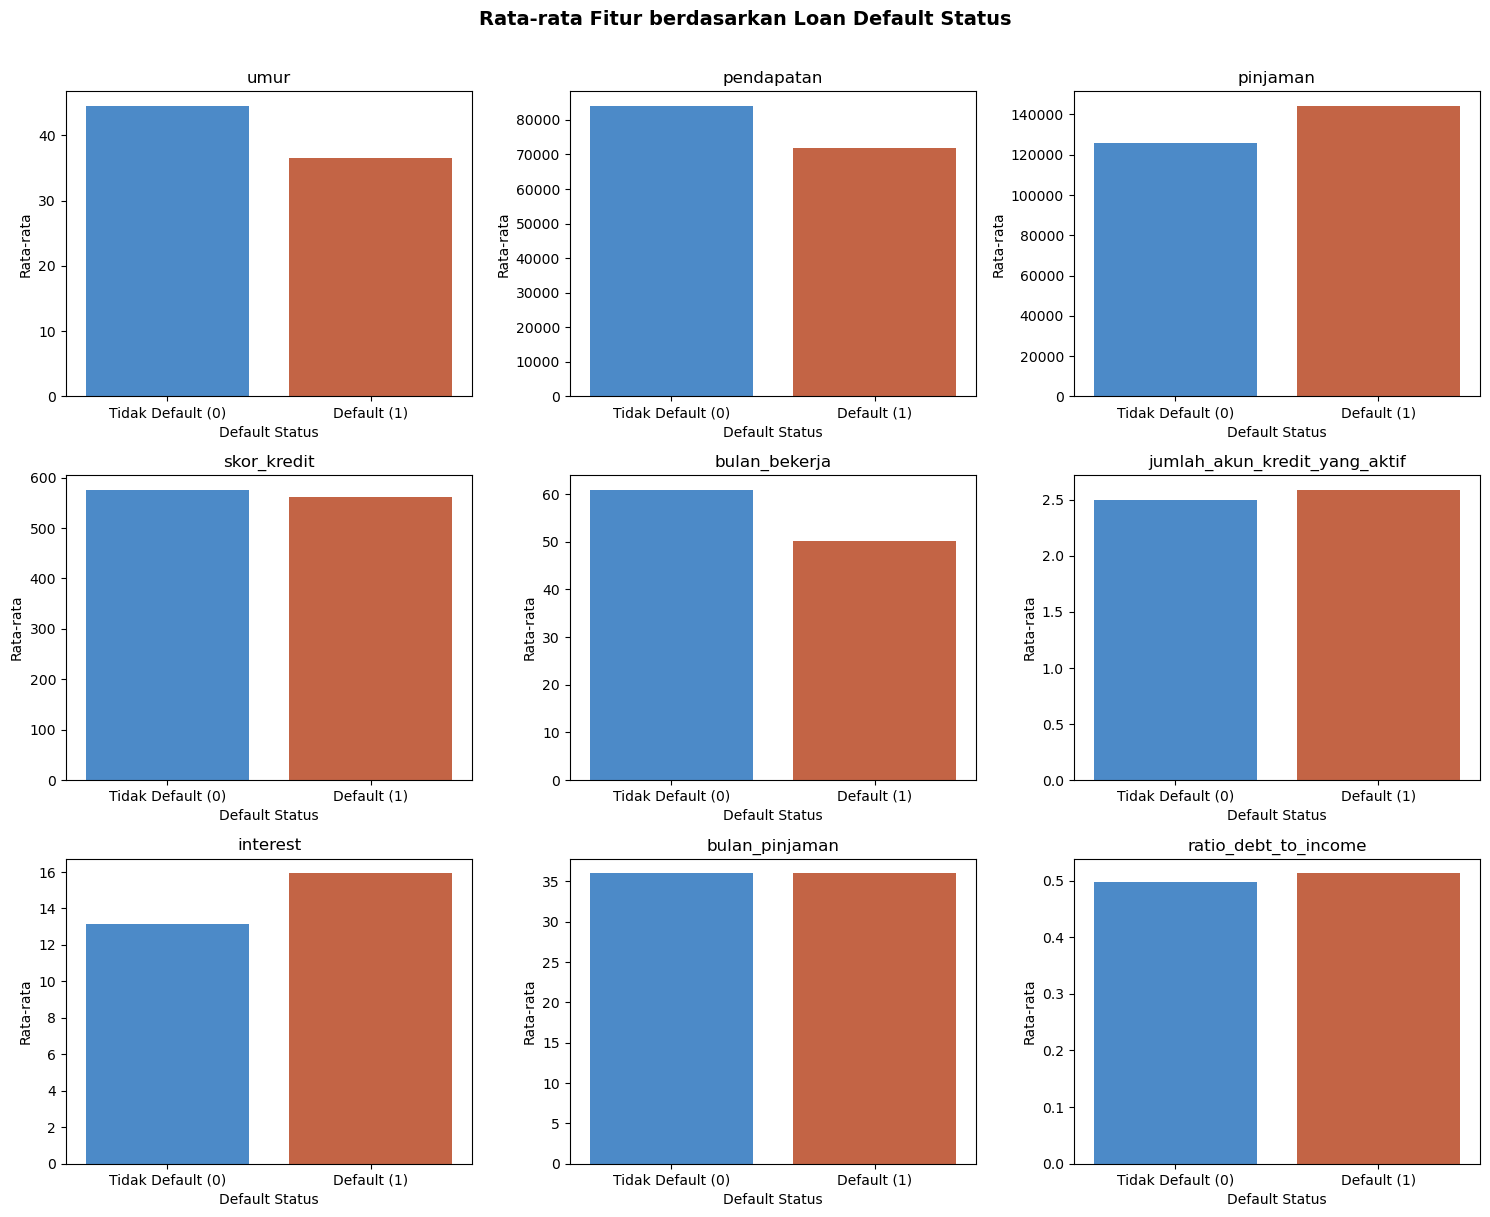

In [16]:
group_reset = group.reset_index()
df_melt = group_reset.melt(id_vars='loan_default_status', var_name='metrik', value_name='rata_rata')

# Plot per metrik (FacetGrid)
metrics = df_melt['metrik'].unique()
n = len(metrics)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, metrik in enumerate(metrics):
    data = df_melt[df_melt['metrik'] == metrik]
    sns.barplot(
        data=data,
        x='loan_default_status',
        y='rata_rata',
        palette=['#378ADD', '#D85A30'],
        ax=axes[i]
    )
    axes[i].set_title(metrik, fontsize=12)
    axes[i].set_xlabel('Default Status')
    axes[i].set_ylabel('Rata-rata')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Tidak Default (0)', 'Default (1)'])

# Sembunyikan axes yang kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Rata-rata Fitur berdasarkan Loan Default Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [17]:
1 = cenderung yang tidak dikasih pinjaman
0 = yang dikasih pinjaman

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (3140811141.py, line 1)

# Encode

## Manual Mapping

In [ ]:
df['level_edukasi'] = df['level_edukasi'].map({"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3})
df['jenis_pekerjaan'] = df['jenis_pekerjaan'].map({"Unemployed": 0, "Self-employed": 1, "Part-time": 2, "Full-time": 3})
df['status_menikah'] = df['status_menikah'].map({"Single": 0, "Divorced": 1, "Married": 2})
df['ada_mortgage'] = df['ada_mortgage'].map({"No": 0, "Yes": 1})
df['punya_tanggungan'] = df['punya_tanggungan'].map({"No": 0, "Yes": 1})
df['tujuan_loan'] = df['tujuan_loan'].map({"Other": 0, "Education": 1, "Auto": 2, "Home": 3, "Business": 4})
df['ada_cosigner'] = df['ada_cosigner'].map({"No": 0, "Yes": 1})
df.drop('id',axis=1, inplace = True)

In [21]:
df.head()

,umur,pendapatan,pinjaman,skor_kredit,bulan_bekerja,jumlah_akun_kredit_yang_aktif,interest,bulan_pinjaman,ratio_debt_to_income,level_edukasi,jenis_pekerjaan,status_menikah,ada_mortgage,punya_tanggungan,tujuan_loan,ada_cosigner,loan_default_status
0,68,15136,148531,491,80,4,14.98,12,0.55,1,1,1,0,0,2,1,1
1,66,148756,40664,825,16,4,11.32,48,0.25,1,0,0,1,0,0,0,0
2,61,42190,138134,378,5,1,20.50,48,0.79,1,0,2,1,0,1,1,0
3,21,89531,33212,558,72,1,14.61,12,0.48,0,2,1,0,1,2,1,1
4,60,36068,72656,659,25,3,7.84,60,0.82,3,2,0,0,1,4,0,0


In [ ]:
categorical = ['umur','pendapatan','pinjaman', 
               'skor_kredit', 'bulan_bekerja', 'jumlah_akun_kredit_yang_aktif',
               'interest','bulan_pinjaman', 'ratio_debt_to_income']

In [ ]:
scaler = StandardScaler()
df[categorical] = scaler.fit_transform(df[categorical])